## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [ ]:
ha = pd.read_csv("https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1")
ha.head()

,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis
0,Magnolia Cassin,60,1,1,117,230,1,160,No Disease
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,Disease
2,Miles Wolf,62,0,3,130,263,1,97,No Disease
3,Mikaila Block,43,1,1,115,303,1,181,Disease
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,Disease


In [ ]:
ha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       204 non-null    object
 1   age        204 non-null    int64 
 2   sex        204 non-null    int64 
 3   cp         204 non-null    int64 
 4   trtbps     204 non-null    int64 
 5   chol       204 non-null    int64 
 6   restecg    204 non-null    int64 
 7   thalach    204 non-null    int64 
 8   diagnosis  204 non-null    object
dtypes: int64(7), object(2)
memory usage: 14.5+ KB


In [ ]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore', drop="first"),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

In [ ]:
from sklearn.linear_model import LogisticRegression
X = ha[["age","chol"]]
y = ha["diagnosis"]

logreg_pipeline = Pipeline(
  [("preprocessing", ct),
  ("logreg", LogisticRegression(max_iter=1000, solver='liblinear'))]
)

param_grid2 = {
  'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
  'logreg__solver': ['liblinear', 'lbfgs']
}

gscv2 = GridSearchCV(logreg_pipeline, param_grid=param_grid2, cv=5, scoring='roc_auc')

In [ ]:
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X, y)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]
b2 = logreg.coef_[0][1]
print(b0)
print(b1)
print(b2)

-1.6386227217799438
0.02792546758993579
-0.0003689643449676458


In [ ]:
age = 55
p = 0.5
logit = np.log(p / (1 - p))
chol_for_50 = -(b0 + b1 * age - logit) / b2
print("Cholesterol for 55 year old with a 50% chance of heart disease:",chol_for_50)

Cholesterol for 55 year old with a 50% chance of heart disease: -278.40631685558384


In [ ]:
p = 0.9
logit = np.log(p / (1 - p))
chol_for_90 = (b0 + b1 * age - logit) / b2
print("Cholesterol for 55 year old with a 90% chance of heart disease:",chol_for_90)

Cholesterol for 55 year old with a 90% chance of heart disease: 6233.519886240973


## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_pipeline = Pipeline(
    [("preprocessing", ct),
     ("lda", LinearDiscriminantAnalysis())]
)

In [ ]:
lda_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x792a7f4b9d60>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x792a7f4b9b80>)])),
                ('lda', LinearDiscriminantAnalysis())])

In [ ]:
b0 = lda_pipeline.named_steps["lda"].intercept_[0]
b_age, b_chol = lda_pipeline.named_steps["lda"].coef_[0]

In [ ]:
age = 55
chol_for_50 = (b0 + b_age * age) / b_chol

In [ ]:
print("Cholesterol for 55 year old with a 50% chance of heart disease:",chol_for_50)

Cholesterol for 55 year old with a 50% chance of heart disease: 248.86402351754165


## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [ ]:
from sklearn.svm import SVC

svc_pipeline = Pipeline(
    [("preprocessing", ct),
     ("svc", SVC(kernel="linear", probability=True))]
)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 100]}
gscv3 = GridSearchCV(svc_pipeline, param_grid, cv=5, scoring='roc_auc')
gscv3.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x792a7f4b9d60>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x792a7f4b9b80>)])),
                                       ('svc',
                                        SVC(kernel='linear',
                                            probability=True))]),
             param_grid={'svc__C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='roc_auc')

In [ ]:
best_svc = gscv3.best_estimator_

b0 = best_svc.named_steps["svc"].intercept_[0]
b_age, b_chol = best_svc.named_steps["svc"].coef_[0]

In [ ]:
age = 55
chol_for_50 = (b0 + b_age * age) / b_chol

print("Best C:",gscv3.best_params_['svc__C'])
print("Cholesterol for 55 year old with a 50% chance of heart disease:",chol_for_50)

Best C: 0.01
Cholesterol for 55 year old with a 50% chance of heart disease: 130.50458898823663


## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

In [ ]:
import matplotlib.pyplot as plt
y_numeric = y.map({'No Disease': 0, 'Disease': 1})

logreg = LogisticRegression(solver='liblinear').fit(X, y)
lda = LinearDiscriminantAnalysis().fit(X, y)
svc_model = SVC(kernel='linear').fit(X, y)

b0_log,(b_age_log, b_chol_log) = logreg.intercept_[0],logreg.coef_[0]
b0_lda,(b_age_lda, b_chol_lda) = lda.intercept_[0],lda.coef_[0]
b0_svc,(b_age_svc, b_chol_svc) = svc_model.intercept_[0],svc_model.coef_[0]

ages = np.linspace(X['age'].min()-2, X['age'].max()+2, 200)
line_log = -(b0_log + b_age_log*ages) / b_chol_log
line_lda = -(b0_lda + b_age_lda*ages) / b_chol_lda
line_svc = -(b0_svc + b_age_svc*ages) / b_chol_svc

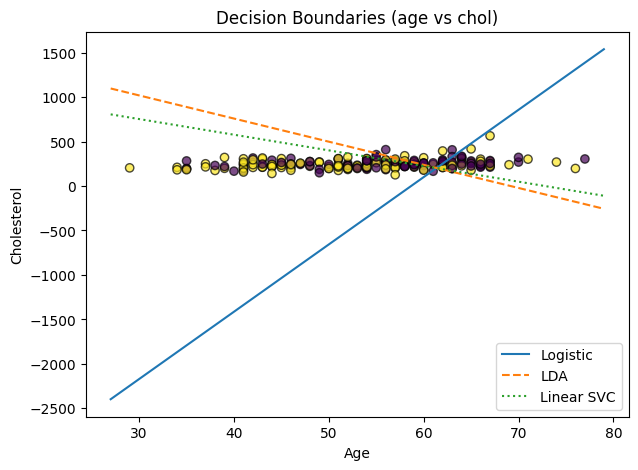

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X['age'], X['chol'], c=y_numeric, edgecolor='k', alpha=0.7)
plt.plot(ages, line_log, label='Logistic')
plt.plot(ages, line_lda, label='LDA', linestyle='--')
plt.plot(ages, line_svc, label='Linear SVC', linestyle=':')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Decision Boundaries (age vs chol)')
plt.legend()
plt.show()